In [2]:
# basic tools
import os
os.environ["OMP_NUM_THREADS"] = "1" # Specificaly for small data set tto avoid memory leak

import numpy as np
import pandas as pd
import duckdb # Data base

#Visual tools
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import plotly.express as px
import plotly.graph_objects as go

#Analysis tools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.stats as stats

In [3]:
# Connect to a database file 
con = duckdb.connect('../aav_manufacturing.db') 

## Calculating derived variables from raw data

In [4]:
query = """SELECT * FROM telemetry_aligned """
df_aligned = con.execute(query).df()

# Calculate instantaneous rates in the aligned dataframe
df_aligned = df_aligned.sort_values(['Batch_ID', 'Hour'])
df_aligned['dt'] = df_aligned.groupby('Batch_ID')['Hour'].diff()

# Growth Rate (mu): (ΔVCD / VCD) / Δt
df_aligned['Growth_Rate'] = df_aligned.groupby('Batch_ID')['VCD'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Production Rate (qp): ΔP / (VCD * Δt)
df_aligned['Production_Rate'] = df_aligned.groupby('Batch_ID')['Product'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Consumption Rate (qg): ΔG / (VCD * Δt)
df_aligned['Consumption_Rate'] = df_aligned.groupby('Batch_ID')['Glucose'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Register with DuckDB
con.register('telemetry_aligned', df_aligned)

## Agregating required data for analysis

In [5]:
query = """
SELECT 
    o.Batch_ID, 
    o.Status, 
    o.Full_Titer, 
    MAX(t.Ammonia) AS Max_Ammonia,
    MAX(t.Lactate) AS Max_Lactate,
    MIN(t.pH) AS Min_pH,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Growth_Rate END) AS Avg_Growth_Rate,
    AVG(CASE WHEN t.Hour >= 72 THEN t.Production_Rate END) AS Avg_Prod_Rate,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Consumption_Rate END) AS Avg_Gluc_Cons
FROM outcomes o
JOIN telemetry_aligned t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Status, o.Full_Titer
"""

df_pca_final = con.execute(query).df()
con.close()

## First PCA for relevant Principal Components

In [6]:
# Define features for the model
feature_cols = ['Max_Ammonia', 'Max_Lactate', 'Min_pH', 
                'Avg_Growth_Rate', 'Avg_Prod_Rate', 'Avg_Gluc_Cons']

# Handle missing values (if any rates couldn't be calculated)
df_pca_final = df_pca_final.dropna(subset=feature_cols)

# Scale the data (Mandatory for PCA)
scaler = StandardScaler()
X = scaler.fit_transform(df_pca_final[feature_cols])

In [7]:
# Run PCA
pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2','PC3','PC4','PC5'])
df_pca_plot['Status'] = df_pca_final['Status'].values

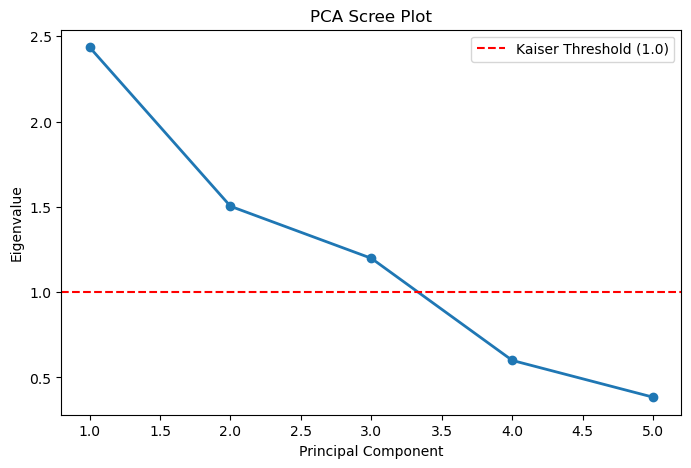

In [8]:
# Calculate Eigenvalues
eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

## Second PCA for visualization and clustering analysis

In [9]:
# Run PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
df_pca_plot['Status'] = df_pca_final['Status'].values

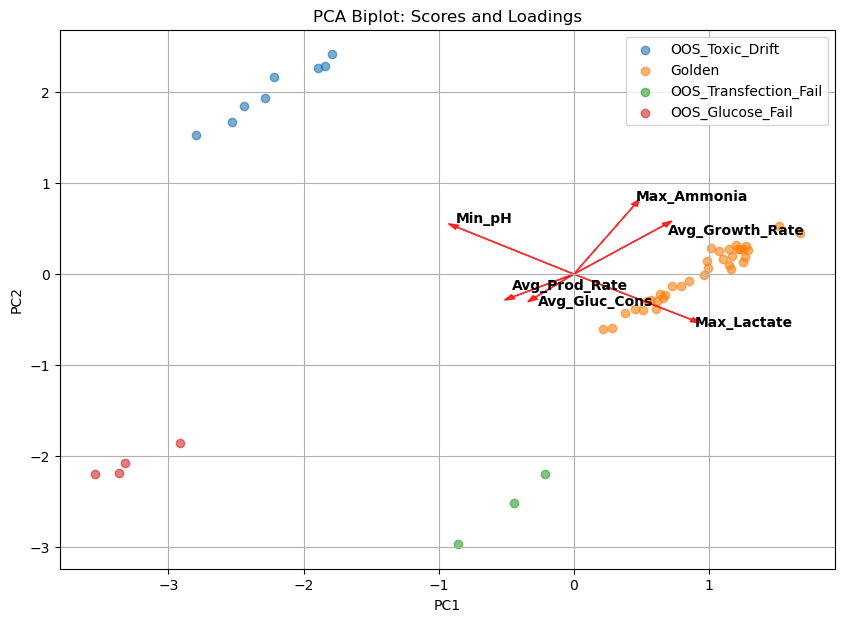

In [10]:
# Extract loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create Biplot
plt.figure(figsize=(10, 7))

# Plot the scores (the batches)
for status in df_pca_final['Status'].unique():
    mask = df_pca_final['Status'] == status
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1], label=status, alpha=0.6)

texts = []
for i, feature in enumerate(feature_cols):
    texts.append(plt.text(loadings[i, 0], loadings[i, 1], feature, fontweight='bold'))
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
# This function iteratively moves text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))


plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot: Scores and Loadings')
plt.legend()
plt.grid(True)
plt.show()

## Golden batch threshold

In [11]:
# 1. Fit PCA ONLY on Golden Batches to define the 'Normal' space
golden_mask = df_pca_final['Status'] == 'Golden'
p_components = 3
pca_golden = PCA(n_components=p_components)
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_pca_final[golden_mask][feature_cols])
pca_golden.fit(train_scaled)

# 2. Project ALL batches (Golden + OOS) into this 'Golden Space'
all_scaled = scaler.transform(df_pca_final[feature_cols])
scores = pca_golden.transform(all_scaled)

eigenvalues = pca_golden.explained_variance_
t2_values = np.sum((scores**2) / eigenvalues, axis=1)

# 2. Calculate the 99% Confidence Threshold (UCL - Upper Control Limit)
# n: number of golden batches used for training
# p: number of PCs retained 
n = df_pca_final[golden_mask].shape[0]
p = p_components
alpha = 0.01
t2_threshold = (p * (n - 1) / (n - p)) * stats.f.ppf(1 - alpha, p, n - p)

# 3. Assign T2 to the dataframe for plotting
df_pca_final['T2_Statistic'] = t2_values
df_pca_final['OOS_Threshold'] = t2_threshold
df_pca_final['Alarm'] = df_pca_final['T2_Statistic'] > df_pca_final['OOS_Threshold']

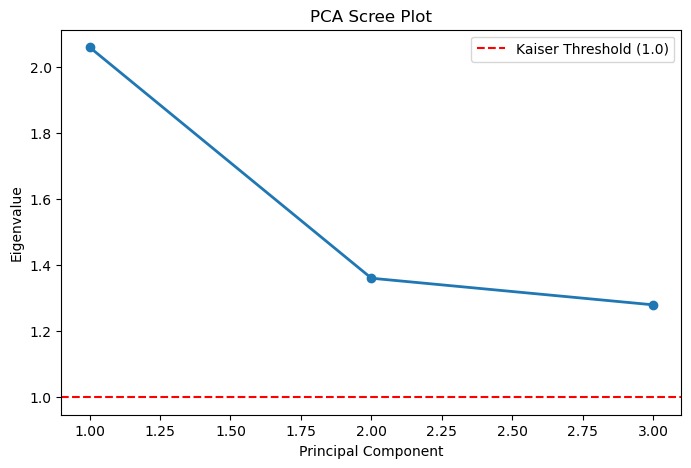

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

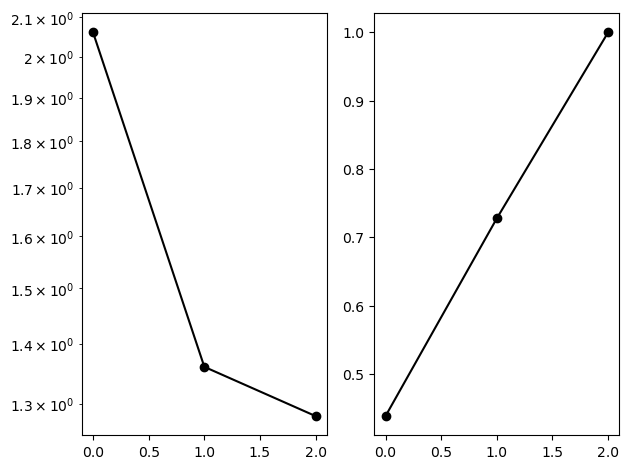

In [13]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
ax1.semilogy(eigenvalues,'-o',color='k')
ax2 = fig1.add_subplot(122)
ax2.plot(np.cumsum(eigenvalues)/np.sum(eigenvalues),'-o',color='k')

plt.tight_layout()
plt.show()

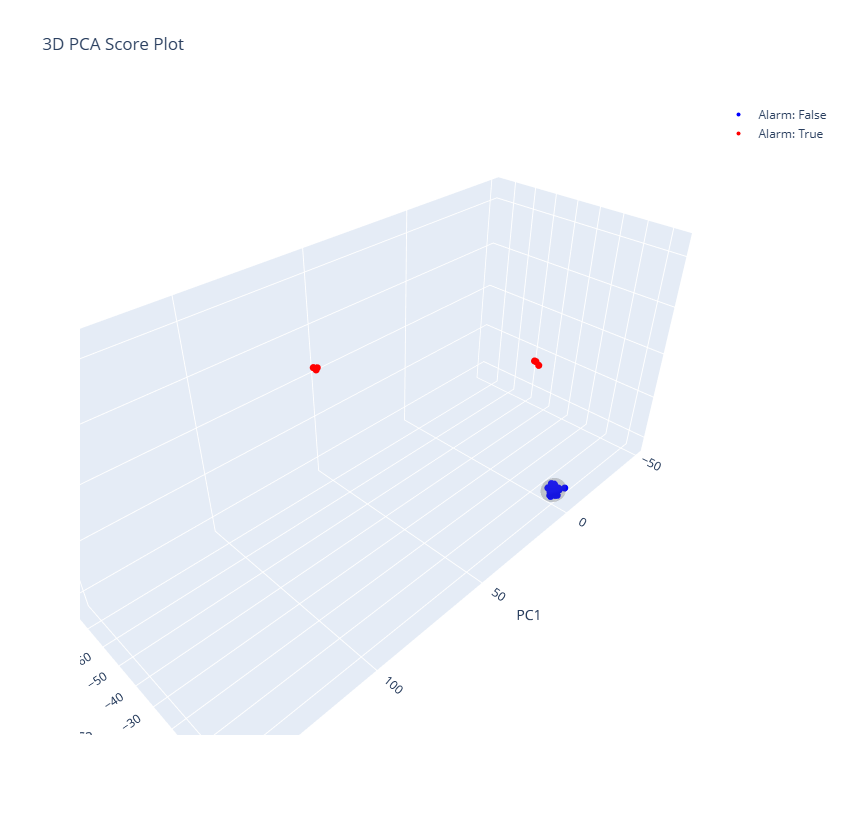

In [14]:
df_plot = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3"])
df_plot['Alarm'] = df_pca_final['Alarm'].values
df_plot['Status'] = df_pca_final['Status'].values

eigenvalues = pca_golden.explained_variance_
radius_x = np.sqrt(t2_threshold * eigenvalues[0])
radius_y = np.sqrt(t2_threshold * eigenvalues[1])
radius_z = np.sqrt(t2_threshold * eigenvalues[2])

# 3. Create the Ellipse Shape
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2 * np.pi, 50)
phi, theta = np.meshgrid(phi, theta)

x_ellipse = radius_x * np.sin(phi) * np.cos(theta)
y_ellipse = radius_y * np.sin(phi) * np.sin(theta)
z_ellipse = radius_z * np.cos(phi)


fig = go.Figure()

for alarm_val, color in zip([False, True], ['blue', 'red']):
    mask = df_plot['Alarm'] == alarm_val
    fig.add_trace(go.Scatter3d(
        x=df_plot.loc[mask, 'PC1'],
        y=df_plot.loc[mask, 'PC2'],
        z=df_plot.loc[mask, 'PC3'],
        mode='markers',
        marker=dict(size=4, color=color),
        name=f'Alarm: {alarm_val}'
    ))

fig.add_trace(go.Surface(
    x=x_ellipse, y=y_ellipse, z=z_ellipse,
    opacity=0.2,
    showscale=False,
    colorscale=[[0, 'gray'], [1, 'gray']],
    name='95% T2 Ellipsoid'
))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot with Hotelling T2 Ellipsoid"
)

fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot"
)
fig.show()

In [15]:
# Reconstruct the data from the PCA space
# This tries to 'guess' what the original values were based on the PCs
reconstructed = pca_golden.inverse_transform(scores)

# Calculate the difference between actual scaled data and reconstruction
residuals = all_scaled - reconstructed
spe_values = np.sum(residuals**2, axis=1)

# Calculate SPE threshold (Simplified Jackson-Mudholkar approximation)
# using the mean and variance of golden residuals:
spe_golden = spe_values[golden_mask]
mean_spe = np.mean(spe_golden)
var_spe = np.var(spe_golden)
g = var_spe / (2 * mean_spe)
h = (2 * mean_spe**2) / var_spe
spe_threshold = g * stats.chi2.ppf(1 - alpha, h)

df_pca_final['SPE_Statistic'] = spe_values
df_pca_final['SPE_Threshold'] = spe_threshold

In [16]:
h_spe_mask = df_pca_final["SPE_Statistic"] > 5.58558 
OOS_mask = df_pca_final["Status"] != "Golden"
alarm_mask = df_pca_final["Alarm"] == True
l_spe_mask = df_pca_final["SPE_Statistic"] < 5.58558 
h_t2_mask = df_pca_final["T2_Statistic"] > 14.214428
df_pca_final[l_spe_mask & h_t2_mask]

,Batch_ID,Status,Full_Titer,Max_Ammonia,Max_Lactate,Min_pH,Avg_Growth_Rate,Avg_Prod_Rate,Avg_Gluc_Cons,T2_Statistic,OOS_Threshold,Alarm,SPE_Statistic,SPE_Threshold


In [22]:
df_pca_final

,Batch_ID,Status,Full_Titer,Max_Ammonia,Max_Lactate,Min_pH,Avg_Growth_Rate,Avg_Prod_Rate,Avg_Gluc_Cons,T2_Statistic,OOS_Threshold,Alarm,SPE_Statistic,SPE_Threshold
0,BATCH_010,OOS_Toxic_Drift,1.561249,5.101116,9.203172,6.776570,0.015049,0.002331,-0.042223,20033.169636,14.214428,True,1668.139234,5.585588
1,BATCH_013,Golden,2.579343,5.183915,30.939462,5.706865,0.014952,0.002327,-0.030233,4.825387,14.214428,False,0.801942,5.585588
2,BATCH_018,Golden,2.320695,5.106228,30.775563,5.705915,0.015134,0.002381,-0.035729,0.698151,14.214428,False,2.269195,5.585588
3,BATCH_021,Golden,2.401969,5.117871,31.209851,5.680879,0.015156,0.002255,-0.037484,12.138691,14.214428,False,0.456131,5.585588
4,BATCH_027,Golden,2.367965,5.079535,30.910155,5.706604,0.014789,0.002359,-0.037229,2.084584,14.214428,False,4.912394,5.585588
5,BATCH_032,OOS_Transfection_Fail,0.764222,1.793364,30.694980,5.686668,0.014992,0.002368,-0.036256,2793.099327,14.214428,True,8388.076111,5.585588
6,BATCH_037,OOS_Transfection_Fail,0.764222,1.784100,30.894881,5.676444,0.014789,0.002385,-0.032812,2703.605261,14.214428,True,8567.976258,5.585588
7,BATCH_045,Golden,2.568870,5.106269,30.978962,5.712136,0.015105,0.002271,-0.033030,3.248251,14.214428,False,2.370136,5.585588
8,BATCH_014,Golden,2.816170,5.087757,30.668523,5.711522,0.015043,0.002352,-0.043036,3.410259,14.214428,False,1.030107,5.585588
9,BATCH_016,Golden,2.480683,5.152275,30.769439,5.702343,0.014983,0.002395,-0.033115,1.857593,14.214428,False,2.656338,5.585588


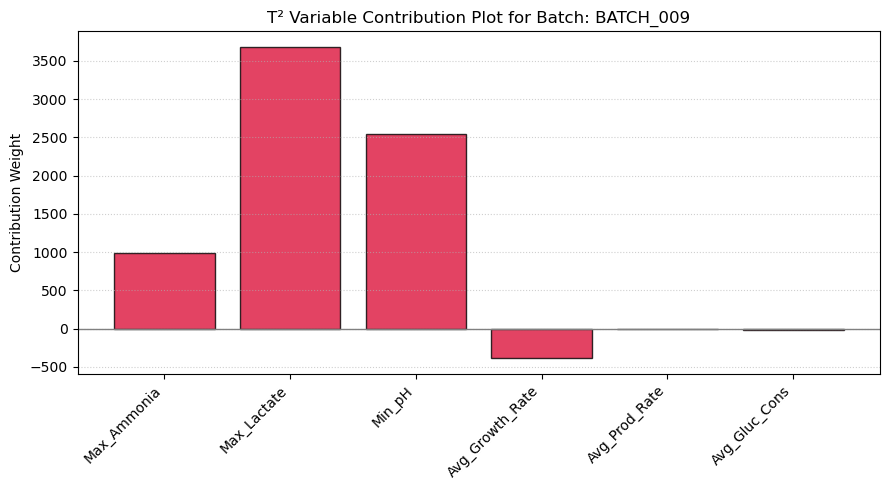

In [27]:
def plot_t2_contribution(df, batch_id, id_col, feature_cols, all_scaled, scores, pca_model):
    batch_idx = df[df[id_col] == batch_id].index[0]
    
    failed_batch_scaled = all_scaled[batch_idx] 
    contributions = np.zeros(len(feature_cols))

    for i in range(len(feature_cols)):
        contribution_i = 0
        for pc_idx in range(pca_model.n_components_):
            loading = pca_model.components_[pc_idx, i]
            score = scores[batch_idx, pc_idx]
            eigenvalue = pca_model.explained_variance_[pc_idx]
            contribution_i += score * loading / eigenvalue
        
        contributions[i] = failed_batch_scaled[i] * contribution_i

    plt.figure(figsize=(9, 5))
    plt.bar(feature_cols, contributions, color='crimson', edgecolor='black', alpha=0.8)
    plt.axhline(0, color='grey', lw=1)
    plt.title(f'T² Variable Contribution Plot for Batch: {batch_id}')
    plt.ylabel('Contribution Weight')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_t2_contribution(
    df=df_pca_final, 
    batch_id="BATCH_009", 
    id_col="Batch_ID", 
    feature_cols= feature_cols, 
    all_scaled=all_scaled, 
    scores=scores, 
    pca_model=pca_golden
)

## Hierarchical clustering

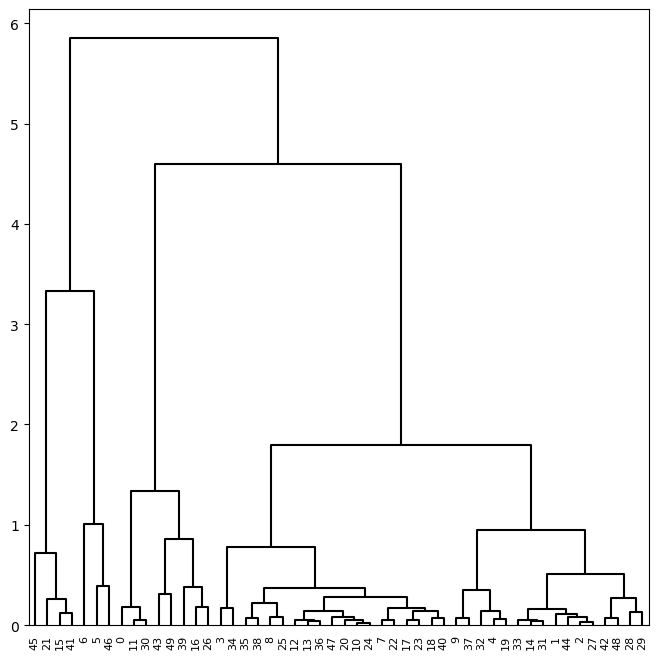

In [19]:
X = df_pca_plot[['PC1', 'PC2']].values
# 'complete' linkage matches your previous code
Z = linkage(X, method='complete')

# 3. Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# mimic your cargs: color_threshold=-np.inf makes the whole tree one color
dendrogram(
    Z, 
    ax=ax, 
    color_threshold=-np.inf, 
    above_threshold_color='black'
)

plt.show()

## K-means cluster

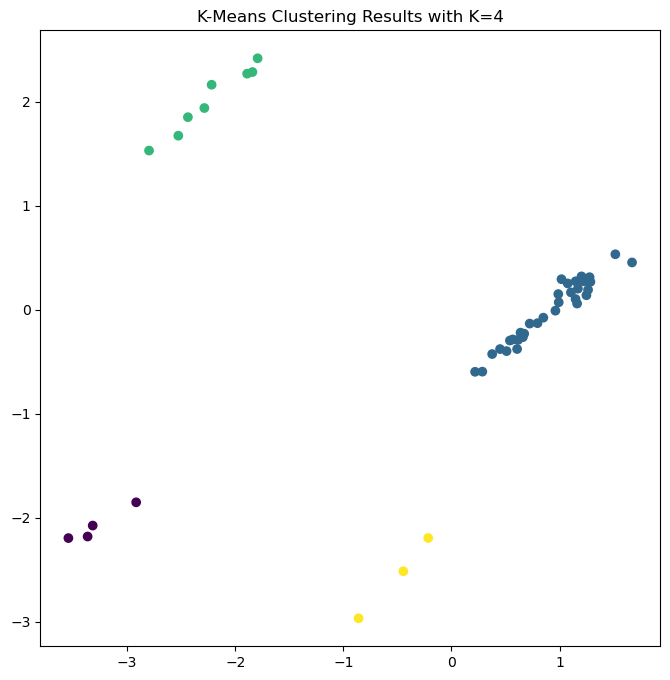

In [20]:
X = df_pca_plot[['PC1', 'PC2']].values
kmeans = KMeans(n_clusters=4, random_state=2, n_init=20).fit(X)

fig , ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=4");